Master: Progettino CNA 
====================================

Fontani Marco, Giraldo Vanessa, Stabile Alessio, Zuffogrosso Anita
----------------

# Import librerie

In [265]:
import networkx as nx

import numpy as np

from statsmodels.distributions.empirical_distribution import ECDF

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from random import *

import powerlaw

# 0. Dataset

Descrizione del dataset scelto:
  - Fonte SNAP
  - Dominio applicativo: social network
  - Tipo di grafo: diretto, non pesato
  - Dimensioni: numero di nodi e archi




In [266]:
wiki = nx.read_edgelist(
    "./Wiki-Vote.txt",
    comments="#",
    delimiter="\t",
    nodetype=int,
    create_using=nx.DiGraph()
)
print(type(wiki))
print(wiki)

<class 'networkx.classes.digraph.DiGraph'>
DiGraph with 7115 nodes and 103689 edges


In [267]:
nx.write_pajek(wiki, "./wiki-vote.pajek")

# 1. Caricamento e statistiche di base

  - Conversione diretto ↔ non diretto 
  - Statistiche di base: numero di nodi, archi

In [268]:
wiki_u = wiki.to_undirected()

print(wiki_u)

#calculation number of nodes and edges
nx.number_of_nodes(wiki_u)
nx.number_of_edges(wiki_u)

Graph with 7115 nodes and 100762 edges


7115

100762

In [269]:
# list of the first 15 nodes
list(wiki_u)[0:15]

# list nodes with attributes -> empty in our case -> not weighted graph
list(wiki_u.nodes.data())[0:15]

# neighbors of node 6
list(wiki_u.neighbors(6))[0:15]


[30, 1412, 3352, 5254, 5543, 7478, 3, 28, 39, 54, 108, 152, 178, 182, 214]

[(30, {}),
 (1412, {}),
 (3352, {}),
 (5254, {}),
 (5543, {}),
 (7478, {}),
 (3, {}),
 (28, {}),
 (39, {}),
 (54, {}),
 (108, {}),
 (152, {}),
 (178, {}),
 (182, {}),
 (214, {})]

[28, 39, 25, 3, 8, 10, 19, 23, 29, 30, 33, 34, 35, 38, 50]

In [270]:
# list edges
list(wiki_u.edges)[0:15]

# list edges with attributes -> no attributes
list(wiki_u.edges.data())[0:15]

# get edges 
list(wiki_u.edges([6, 3]))

[(30, 1412),
 (30, 3352),
 (30, 5254),
 (30, 5543),
 (30, 7478),
 (30, 3),
 (30, 25),
 (30, 6),
 (30, 8),
 (30, 19),
 (30, 23),
 (30, 4),
 (30, 10),
 (30, 5),
 (30, 7)]

[(30, 1412, {}),
 (30, 3352, {}),
 (30, 5254, {}),
 (30, 5543, {}),
 (30, 7478, {}),
 (30, 3, {}),
 (30, 25, {}),
 (30, 6, {}),
 (30, 8, {}),
 (30, 19, {}),
 (30, 23, {}),
 (30, 4, {}),
 (30, 10, {}),
 (30, 5, {}),
 (30, 7, {})]

[(6, 28),
 (6, 39),
 (6, 25),
 (6, 3),
 (6, 8),
 (6, 10),
 (6, 19),
 (6, 23),
 (6, 29),
 (6, 30),
 (6, 33),
 (6, 34),
 (6, 35),
 (6, 38),
 (6, 50),
 (6, 54),
 (6, 55),
 (6, 56),
 (6, 61),
 (6, 80),
 (6, 86),
 (6, 89),
 (6, 93),
 (6, 94),
 (6, 127),
 (6, 130),
 (6, 132),
 (6, 135),
 (6, 140),
 (6, 147),
 (6, 151),
 (6, 153),
 (6, 154),
 (6, 163),
 (6, 167),
 (6, 168),
 (6, 171),
 (6, 175),
 (6, 178),
 (6, 182),
 (6, 183),
 (6, 216),
 (6, 219),
 (6, 226),
 (6, 227),
 (6, 228),
 (6, 232),
 (6, 236),
 (6, 243),
 (6, 250),
 (6, 252),
 (6, 257),
 (6, 258),
 (6, 259),
 (6, 261),
 (6, 271),
 (6, 273),
 (6, 274),
 (6, 280),
 (6, 285),
 (6, 286),
 (6, 290),
 (6, 298),
 (6, 299),
 (6, 300),
 (6, 301),
 (6, 304),
 (6, 306),
 (6, 317),
 (6, 319),
 (6, 322),
 (6, 325),
 (6, 339),
 (6, 348),
 (6, 349),
 (6, 356),
 (6, 358),
 (6, 359),
 (6, 362),
 (6, 363),
 (6, 370),
 (6, 371),
 (6, 373),
 (6, 377),
 (6, 378),
 (6, 379),
 (6, 390),
 (6, 391),
 (6, 392),
 (6, 394),
 (6, 396),
 (6, 402),
 (6, 405),
 (6

In [271]:
# list of the edges of the node 3
list(wiki.edges(3)) # in-edges & out-edges
list(wiki.out_edges(3)) # out-edges -> equal to the previous one because the graph is directed
list(wiki.in_edges(3)) # in-edges

#degree node 3
degree_3 = len(wiki.out_edges(3)) + len(wiki.in_edges(3))
print (degree_3)

# check if edge exists
wiki.has_edge(6, 3)

wiki_u.has_edge(6, 3)

[(3, 28),
 (3, 30),
 (3, 39),
 (3, 54),
 (3, 108),
 (3, 152),
 (3, 178),
 (3, 182),
 (3, 214),
 (3, 271),
 (3, 286),
 (3, 300),
 (3, 348),
 (3, 349),
 (3, 371),
 (3, 567),
 (3, 581),
 (3, 584),
 (3, 586),
 (3, 590),
 (3, 604),
 (3, 611),
 (3, 8283)]

[(3, 28),
 (3, 30),
 (3, 39),
 (3, 54),
 (3, 108),
 (3, 152),
 (3, 178),
 (3, 182),
 (3, 214),
 (3, 271),
 (3, 286),
 (3, 300),
 (3, 348),
 (3, 349),
 (3, 371),
 (3, 567),
 (3, 581),
 (3, 584),
 (3, 586),
 (3, 590),
 (3, 604),
 (3, 611),
 (3, 8283)]

[(25, 3),
 (6, 3),
 (10, 3),
 (14, 3),
 (17, 3),
 (19, 3),
 (20, 3),
 (24, 3),
 (54, 3),
 (28, 3),
 (34, 3),
 (35, 3),
 (26, 3),
 (41, 3),
 (46, 3),
 (47, 3),
 (29, 3),
 (59, 3),
 (73, 3),
 (94, 3),
 (111, 3),
 (127, 3),
 (138, 3),
 (139, 3),
 (143, 3),
 (178, 3),
 (180, 3),
 (223, 3),
 (269, 3),
 (284, 3),
 (292, 3)]

54


True

True

# 2. Struttura connessa

  - Analisi delle componenti connesse (deboli/forti se diretto)
  - Identificazione e estrazione della Giant Component (GC)
  - Dimensioni delle componenti connesse

In [272]:
# Check whether the graph is connected or not
nx.is_strongly_connected(wiki)
nx.is_weakly_connected(wiki)

wiki_cc = list(nx.weakly_connected_components(wiki))

# we extract the GC from the wiki graph
wiki_GC = nx.subgraph(wiki, max(wiki_cc, key=len))
nx.is_weakly_connected(wiki_GC)

print(f'The original wiki graph has {wiki.number_of_nodes()} nodes and {wiki.number_of_edges()} edges')
print(f'The GC in the wiki graph has {wiki_GC.number_of_nodes()} nodes and {wiki_GC.number_of_edges()} edges')

# number of connected components
nx.number_weakly_connected_components(wiki)

# sizes of each connected component
[len(c) for c in sorted(wiki_cc, key=len, reverse=True)][0:7]



False

False

True

The original wiki graph has 7115 nodes and 103689 edges
The GC in the wiki graph has 7066 nodes and 103663 edges


24

[7066, 3, 3, 3, 2, 2, 2]

### Working with GC

In [273]:
# Select only nodes with degree > 450 from the wiki Giant Component
vs = [n for n in list(wiki_GC.nodes) if wiki_GC.degree(n) > 450]

#building subgraph
wiki_GC_sub = wiki_GC.subgraph(vs)

nx.number_weakly_connected_components(wiki_GC_sub)

[len(cc) for cc in nx.weakly_connected_components(wiki_GC_sub)]

1

[16]

# 3. Analisi del grado dei nodi

  - Istogramma e CCDF del grado (scala lin-log, log-log)
  - Discussione: il grafo sembra scale-free?

<Figure size 900x700 with 0 Axes>

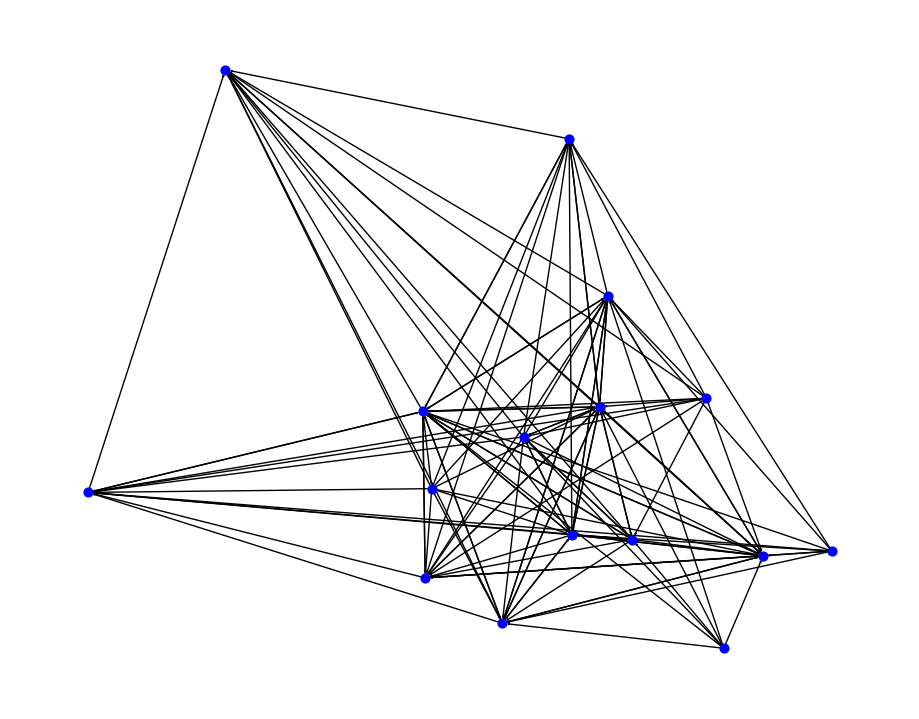

In [274]:
# Plotting graph using graph built previously with degree > 450
visual_style = {}    
visual_style["with_labels"] = False
visual_style["node_size"] = 40
visual_style["node_color"] = 'blue'
visual_style["node_shape"] = 'o'
visual_style["arrowsize"] = 2
visual_style["pos"] = nx.spring_layout(wiki_GC_sub, seed = 22)

plt.figure(figsize=(9, 7))

nx.draw(wiki_GC_sub, **visual_style)

Degree Analysis

In [275]:
#list of the degree of each node of the graph
wiki_deg = list(wiki_GC.degree())

#list of the first 7 elements of the degree list
wiki_deg[0:7] 

#giant component in-degree list
wiki_GC.in_degree()

#giant component out-degree list
wiki_GC.out_degree()


[(30, 28),
 (1412, 29),
 (3352, 537),
 (5254, 298),
 (5543, 282),
 (7478, 92),
 (3, 54)]

InDegreeView({30: 23, 1412: 29, 3352: 264, 5254: 265, 5543: 145, 7478: 92, 3: 31, 28: 122, 39: 28, 54: 40, 108: 11, 152: 51, 178: 35, 182: 32, 214: 175, 271: 192, 286: 19, 300: 22, 348: 35, 349: 15, 371: 24, 567: 26, 581: 12, 584: 14, 586: 10, 590: 32, 604: 13, 611: 25, 8283: 10, 25: 0, 6: 20, 8: 44, 19: 22, 23: 22, 29: 41, 33: 34, 35: 110, 50: 32, 55: 67, 75: 69, 80: 43, 86: 108, 94: 27, 127: 19, 154: 18, 192: 27, 224: 18, 226: 21, 246: 23, 252: 38, 255: 26, 257: 25, 261: 24, 273: 13, 280: 22, 282: 101, 299: 158, 302: 24, 306: 22, 308: 41, 310: 43, 322: 43, 325: 45, 339: 20, 356: 43, 358: 12, 363: 18, 370: 45, 373: 20, 377: 28, 379: 21, 407: 135, 415: 66, 422: 16, 428: 22, 439: 70, 488: 22, 514: 20, 545: 49, 549: 62, 560: 40, 592: 17, 600: 77, 645: 8, 650: 14, 659: 44, 664: 26, 667: 35, 673: 42, 675: 25, 696: 33, 706: 24, 723: 25, 739: 60, 756: 64, 857: 115, 864: 20, 893: 53, 959: 78, 994: 33, 1131: 34, 3755: 121, 8282: 11, 8284: 10, 4: 0, 10: 15, 38: 14, 56: 149, 130: 20, 140: 22, 14

OutDegreeView({30: 5, 1412: 0, 3352: 273, 5254: 33, 5543: 137, 7478: 0, 3: 23, 28: 133, 39: 41, 54: 7, 108: 2, 152: 21, 178: 63, 182: 79, 214: 0, 271: 0, 286: 0, 300: 0, 348: 21, 349: 1, 371: 117, 567: 2, 581: 0, 584: 5, 586: 13, 590: 8, 604: 8, 611: 0, 8283: 0, 25: 90, 6: 302, 8: 182, 19: 39, 23: 74, 29: 150, 33: 24, 35: 65, 50: 14, 55: 64, 75: 31, 80: 59, 86: 122, 94: 80, 127: 132, 154: 61, 192: 19, 224: 13, 226: 25, 246: 1, 252: 0, 255: 86, 257: 8, 261: 8, 273: 7, 280: 76, 282: 39, 299: 0, 302: 13, 306: 244, 308: 142, 310: 230, 322: 0, 325: 25, 339: 80, 356: 18, 358: 0, 363: 3, 370: 0, 373: 0, 377: 0, 379: 0, 407: 145, 415: 4, 422: 0, 428: 0, 439: 8, 488: 4, 514: 0, 545: 24, 549: 4, 560: 8, 592: 12, 600: 214, 645: 16, 650: 98, 659: 14, 664: 13, 667: 19, 673: 5, 675: 1, 696: 6, 706: 95, 723: 1, 739: 0, 756: 0, 857: 0, 864: 0, 893: 0, 959: 12, 994: 45, 1131: 0, 3755: 0, 8282: 0, 8284: 0, 4: 29, 10: 86, 38: 14, 56: 24, 130: 13, 140: 30, 147: 58, 151: 74, 232: 23, 243: 2, 341: 47, 606: 

In [276]:
#maximum degree of the degree node list
id_max, dmax = max(wiki_deg, key=lambda x: x[1])

print(f'The node with the max degree: ({id_max}, {dmax})')


# list of node degrees, sorted
sorted(wiki_deg, key=lambda x: x[1], reverse=True)[0:7]


The node with the max degree: (2565, 1167)


[(2565, 1167),
 (1549, 832),
 (766, 773),
 (11, 743),
 (1166, 743),
 (457, 732),
 (2688, 618)]

In [277]:
nei = list(wiki_GC.neighbors(id_max))
succ = list(wiki_GC.successors(id_max)) #the giant component in this case is direct, so the number of neighbors is equal to the number of the successors 
pred = list(wiki_GC.predecessors(id_max))

#print the degree
print(len(succ) + (len(pred)))

1167


In [278]:
# the undirected version of the Giant Component
wiki_GC_u = wiki_GC.to_undirected()

#list of the degree of each node
wiki_deg_u = list(wiki_GC_u.degree())

#maximum degree of the degree node list
id_max, dmax = max(wiki_deg_u, key=lambda x: x[1])

print(f'The node with the max degree: ({id_max}, {dmax})')

# list of node degrees, sorted
sorted(wiki_deg_u, key=lambda x: x[1], reverse=True)[0:20]

# neighbors
nei = list(wiki_GC_u.neighbors(id_max))
len(nei)

The node with the max degree: (2565, 1065)


[(2565, 1065),
 (766, 773),
 (11, 743),
 (1549, 740),
 (457, 732),
 (1166, 688),
 (2688, 618),
 (1374, 533),
 (1151, 517),
 (5524, 495),
 (3352, 477),
 (4037, 467),
 (737, 446),
 (2485, 435),
 (2328, 425),
 (3456, 414),
 (2871, 410),
 (5802, 410),
 (1608, 406),
 (15, 403)]

1065

Degree density and CCDF

[0, 2269, 637, 388, 245, 165, 159, 139, 111, 89]


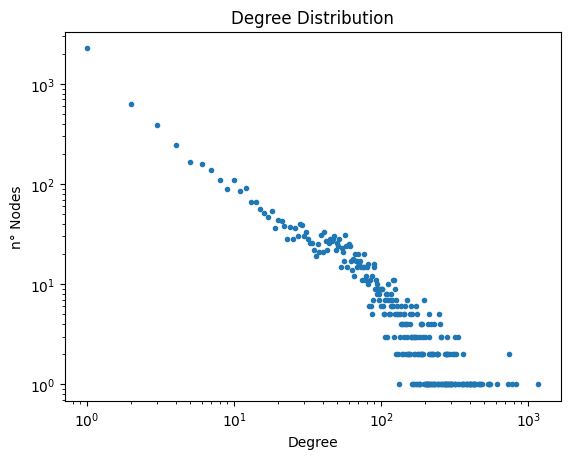

In [279]:
hist = nx.degree_histogram(wiki_GC) #list in which degree is the index and the value in each cell of the list is the number of the nodes that have ^index degree
#example: [0 nodes with 0 degree, xxxx nodes with 1 degree, yyyy nodes with 2 degree, ...]

print(hist[0:10])

_ = plt.plot(range(0, len(hist)), hist, ".")
_ = plt.title("Degree Distribution")
_ = plt.xlabel("Degree")
_ = plt.ylabel("n° Nodes")
_ = plt.loglog()

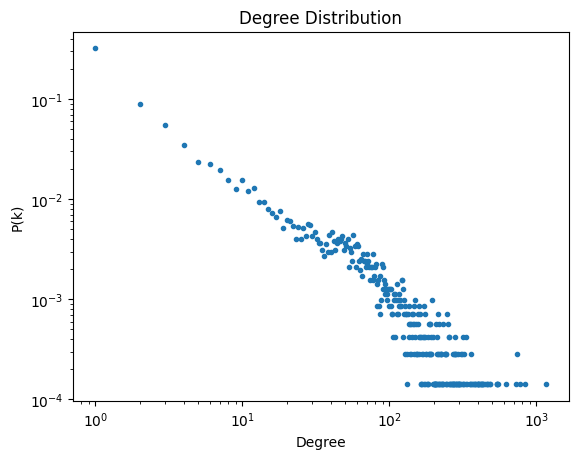

In [280]:
# pmf -> probability mass function
# pk is the normalized list (normalized in respect of the total number of the nodes)
pk = [c / sum(hist) for c in hist]

_ = plt.plot(range(0, len(pk)), pk, ".")
_ = plt.title("Degree Distribution")
_ = plt.xlabel("Degree")
_ = plt.ylabel("P(k)")
_ = plt.loglog()

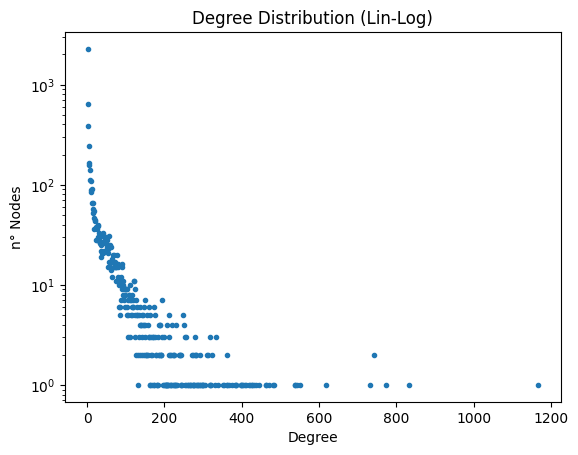

In [281]:
# lin-log graphic
_ = plt.plot(range(0, len(hist)), hist, ".")
_ = plt.title("Degree Distribution (Lin-Log)")
_ = plt.xlabel("Degree")
_ = plt.ylabel("n° Nodes")
_ = plt.yscale('log')

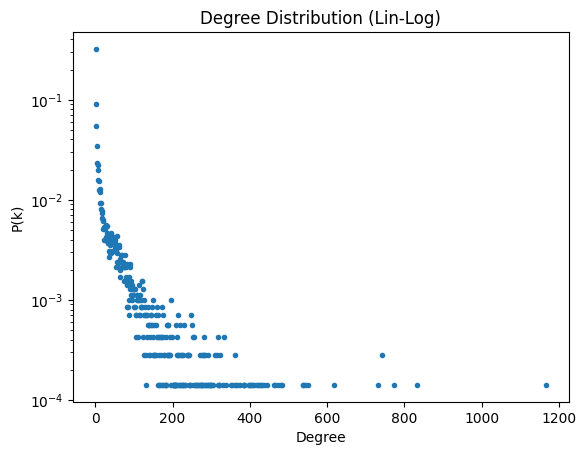

In [282]:
# pmf -> probability mass function
# pk is the normalized list (normalized in respect of the total number of the nodes)
pk = [c / sum(hist) for c in hist]
 
# lin-log graphic
_ = plt.plot(range(0, len(pk)), pk, ".")
_ = plt.title("Degree Distribution (Lin-Log)")
_ = plt.xlabel("Degree")
_ = plt.ylabel("P(k)")
_ = plt.yscale('log')

CCDF

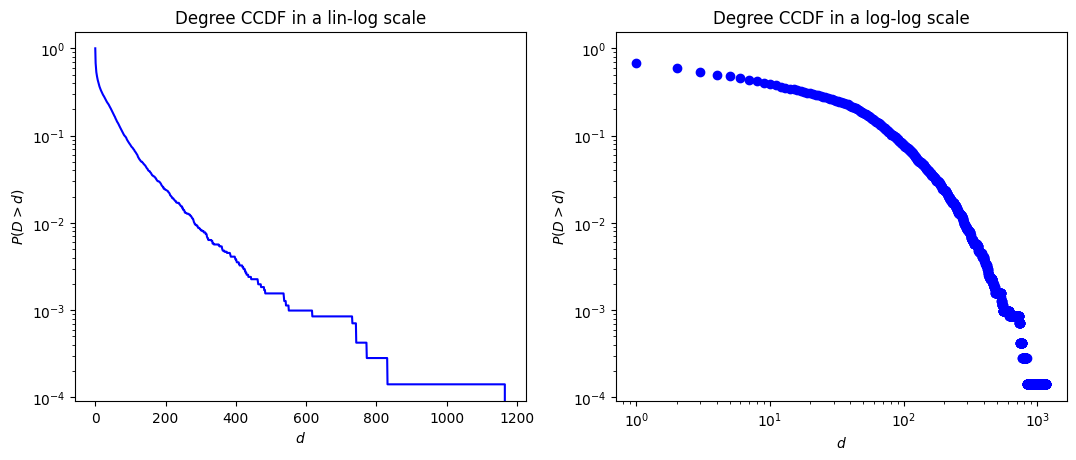

In [283]:
##list of the GC degrees
wiki_deg_list = list(dict(wiki_GC.degree()).values()) 

#ECDF
deg_cdf = ECDF(wiki_deg_list)

# scale the fig size twice in width
default_sizes = plt.rcParams["figure.figsize"]
#sizing
fig_sizes = (2*default_sizes[0], default_sizes[1])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = fig_sizes)

#calcutation of x-axes values
degs = list(range(0,max(wiki_deg_list)+1)) 

_ = ax1.plot(degs, 1-deg_cdf(degs), 'b-')
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("$P(D>d)$")
_ = ax1.set_title("Degree CCDF in a lin-log scale")
_ = ax1.set_yscale('log')

_ = ax2.loglog(degs, 1-deg_cdf(degs), 'bo')
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("$P(D>d)$")
_ = ax2.set_title("Degree CCDF in a log-log scale")

In [284]:
#seems to be a scale-free graph. Heavy-tail, not many hubs and nodes without many links.

# 4. Proprietà topologiche della GC
  - Clustering: transitività globale (C₁) e clustering medio locale (C₂)
  - Cammini minimi: distanza media
  - Assortatività: coefficiente di Pearson sui gradi; analisi knn e knnk


Assortativity

In [285]:
##use of undirected graph
nx.degree_assortativity_coefficient(wiki_GC_u)


-0.0833028111956225

In [286]:
## average degree of the neighbors of each node
wiki_knn = nx.average_neighbor_degree(wiki_GC_u)
print(wiki_knn)

{30: 150.39285714285714, 1412: 87.17241379310344, 3352: 127.36687631027253, 5254: 123.07560137457045, 5543: 133.97338403041826, 7478: 150.72826086956522, 3: 79.6078431372549, 28: 64.89565217391305, 39: 77.22222222222223, 54: 109.42222222222222, 108: 25.5, 152: 75.23880597014926, 178: 98.47916666666667, 182: 128.16216216216216, 214: 103.65142857142857, 271: 94.13020833333333, 286: 143.6315789473684, 300: 84.63636363636364, 348: 94.01785714285714, 349: 81.1875, 371: 115.95652173913044, 567: 91.0, 581: 94.0, 584: 113.89473684210526, 586: 103.1304347826087, 590: 103.71794871794872, 604: 98.9047619047619, 611: 112.32, 8283: 40.5, 25: 80.9, 6: 71.72929936305732, 8: 62.07834101382488, 19: 95.47368421052632, 23: 80.65217391304348, 29: 93.03351955307262, 33: 102.26785714285714, 35: 104.27044025157232, 50: 113.4186046511628, 55: 76.35, 75: 65.42105263157895, 80: 80.54081632653062, 86: 96.79357798165138, 94: 77.62135922330097, 127: 134.39333333333335, 154: 112.17105263157895, 192: 105.18604651162

In [287]:
#the output is a dict {degree_k : average_of_average_degree_of_neighbors}
wiki_knnk = nx.average_degree_connectivity(wiki_GC_u)
print(wiki_knnk)

{28: 159.3113553113553, 29: 141.59459459459458, 477: 127.36687631027253, 291: 123.14089347079037, 263: 127.68948035487959, 92: 146.08423913043478, 51: 169.14630467571644, 230: 97.51304347826087, 63: 165.49289891395154, 45: 171.69761904761904, 12: 144.31182795698925, 67: 168.82632293080053, 96: 146.58333333333334, 111: 152.14264264264264, 175: 136.47619047619048, 192: 117.0546875, 19: 131.26634768740033, 22: 148.0121951219512, 56: 152.86904761904762, 16: 147.59551886792454, 138: 136.28115942028987, 27: 161.16487455197134, 23: 137.9301242236025, 39: 161.7312113174182, 21: 150.9954648526077, 25: 141.83384615384617, 10: 148.5890909090909, 90: 140.1288888888889, 314: 110.18789808917198, 217: 99.97926267281106, 57: 167.91979949874687, 179: 132.12988826815644, 159: 150.07075471698113, 43: 160.56622851365015, 120: 141.13611111111112, 95: 114.26315789473684, 98: 134.46224489795918, 218: 111.22247706422019, 103: 140.3135922330097, 150: 145.22833333333332, 76: 154.9306220095694, 44: 160.741666666

[28, 29, 477, 291, 263]

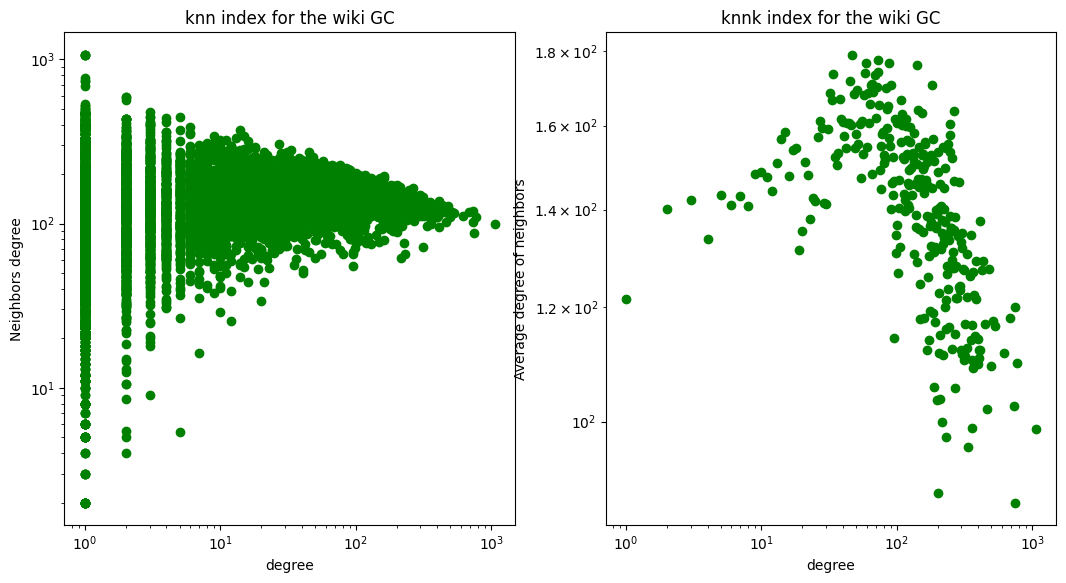

In [288]:
deg_list = [x[1] for x in list(wiki_GC_u.degree())]
deg_list[0:5]

#ax1: y-axes -> average degree of a node, x -> degrees
#ax2: y-axes -> average of the average degree of neighbors , x -> degree
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[0]))
_ = ax1.loglog(deg_list, wiki_knn.values(), 'og')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("knn index for the wiki GC")

_ = ax2.loglog(wiki_knnk.keys(), wiki_knnk.values(), 'og')
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("knnk index for the wiki GC")



## Clustering

In [289]:
# global clustering coefficient
nx.transitivity(wiki_GC_u)

# local clustering coefficient
nx.average_clustering(wiki_GC_u)

#dict{node: local clustering coefficient}
local_clust = nx.clustering(wiki_GC_u)

0.12547917487219654

0.14187491841626323

In [290]:
local_clust

{30: 0.15079365079365079,
 1412: 0.04926108374384237,
 3352: 0.11341014393178656,
 5254: 0.08517596871667259,
 5543: 0.14312251473021217,
 7478: 0.0957955088389871,
 3: 0.2196078431372549,
 28: 0.08767799506360358,
 39: 0.18842805939580134,
 54: 0.26161616161616164,
 108: 0.12121212121212122,
 152: 0.1560379918588874,
 178: 0.10328947368421053,
 182: 0.13185913185913187,
 214: 0.06311986863711001,
 271: 0.1024760034904014,
 286: 0.38011695906432746,
 300: 0.18614718614718614,
 348: 0.1357142857142857,
 349: 0.21666666666666667,
 371: 0.10102612927113086,
 567: 0.19373219373219372,
 581: 0.2878787878787879,
 584: 0.39766081871345027,
 586: 0.22529644268774704,
 590: 0.2658569500674764,
 604: 0.23809523809523808,
 611: 0.17,
 8283: 0.08888888888888889,
 25: 0.1867665418227216,
 6: 0.06395881239698012,
 8: 0.09788359788359788,
 19: 0.30200501253132833,
 23: 0.15790731008122313,
 29: 0.10445044253342539,
 33: 0.21688311688311687,
 35: 0.15118223071411513,
 50: 0.35105204872646734,
 55: 0.1

Average path length

In [291]:
src = sample(list(wiki_GC_u.nodes), 1000)
trg = sample(list(wiki_GC_u.nodes), 1000)

# it returns the number of hops
n_hops_u = [nx.shortest_path_length(wiki_GC_u, source = src[i], target = trg[i]) for i in range(1000)]

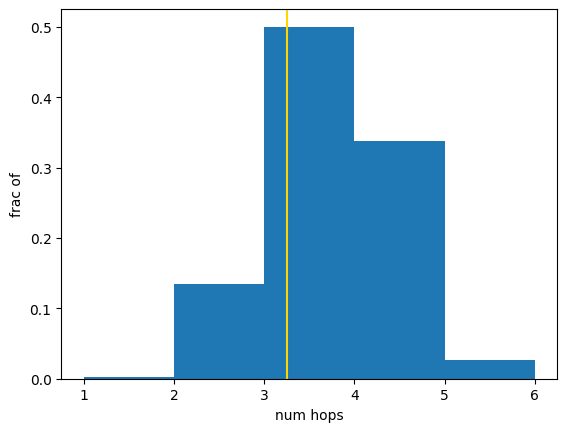

In [292]:
_, _, _ = plt.hist(n_hops_u, bins = range(1, max(n_hops_u) + 2), density=True)
_ = plt.axvline(np.mean(n_hops_u), color = "gold")
_ = plt.xlabel("num hops")
_ = plt.ylabel("frac of")

The average number of hops is:

In [293]:
np.mean(n_hops_u)

np.float64(3.252)

# 5. Confronto con grafi sintetici

## Random graphs (ER)

Generare i tre grafi sintetici di riferimento con le stesse dimensioni (nodi, grado medio) della GC del dataset:

- Erdős–Rényi (ER)
- Barabási–Albert (BA)
- Configuration Model (CM)

In [294]:
avg_degree = sum(dict(wiki_GC_u.degree()).values())/wiki_GC_u.number_of_nodes()
print(f'The average degree of the wiki graph is {avg_degree}')

er_p_GC = avg_degree/(wiki_GC_u.number_of_nodes() -1) # avg_degree / (N-1)
print(f'The p we set is {er_p_GC}')

er_wiki_all = nx.erdos_renyi_graph(wiki_GC_u.number_of_nodes(), er_p_GC)
# er_wiki_all = nx.fast_gnp_random_graph(wiki_GC_u.number_of_nodes(), er_p_GC, seed=42)  # alternative function

er_wiki = er_wiki_all.subgraph(max(nx.connected_components(er_wiki_all), key=len))

The average degree of the wiki graph is 28.512878573450326
The p we set is 0.004035793145569756


In [295]:
print(f'Number of nodes in wiki (GC): {wiki_GC_u.number_of_nodes()}')
print(f'Number of nodes in ER: {er_wiki_all.number_of_nodes()}')
print(f'Number of nodes in ER (GC): {er_wiki.number_of_nodes()}')

print(f'Number of edges in wiki (GC): {wiki_GC_u.number_of_edges()}')
print(f'Number of edges in ER: {er_wiki_all.number_of_edges()}')
print(f'Number of edges in ER (GC): {er_wiki.number_of_edges()}')

print(f'Number of connected components in ER: {len(list(nx.connected_components(er_wiki_all)))}')
sorted([len(cc) for cc in list(nx.connected_components(er_wiki_all))], reverse=True)



Number of nodes in wiki (GC): 7066
Number of nodes in ER: 7066
Number of nodes in ER (GC): 7066
Number of edges in wiki (GC): 100736
Number of edges in ER: 100588
Number of edges in ER (GC): 100588
Number of connected components in ER: 1


[7066]

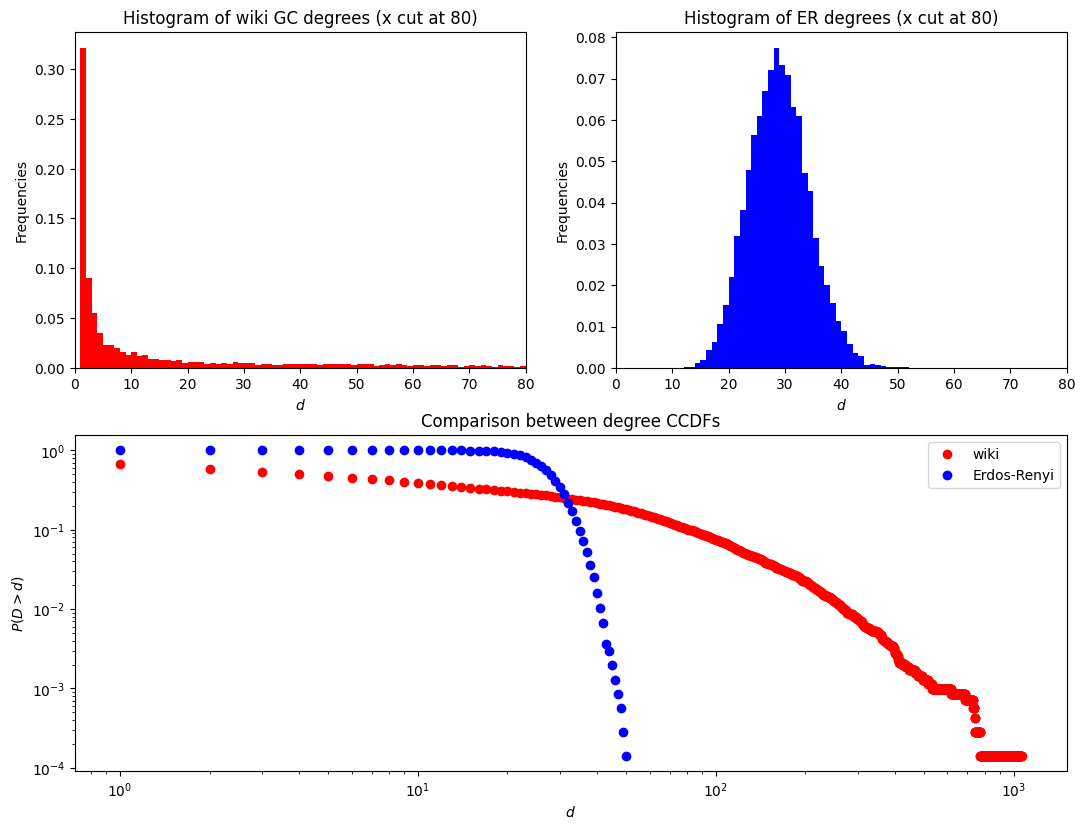

In [296]:
# sizing 
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

gs = gridspec.GridSpec(2, 2)



ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[1,:])

d_am = list(dict(wiki_GC_u.degree()).values())
_,_,_ = ax1.hist(d_am, bins=range(1,max(d_am)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of wiki GC degrees (x cut at 80)")

d_er = list(dict(er_wiki.degree()).values())
_,_,_ = ax2.hist(d_er, bins=range(1,max(d_er)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of ER degrees (x cut at 80)")


wiki_ecdf = ECDF(d_am)
er_ecdf = ECDF(d_er)
x = np.arange(1,max(d_am)+1)
_ = ax3.loglog(x, 1-wiki_ecdf(x), 'ro', label = 'wiki')
x = np.arange(1,max(d_er)+1)
_ = ax3.loglog(x, 1-er_ecdf(x), 'bo', label = 'Erdos-Renyi')
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

In [297]:
print(f'Pearson wiki = {nx.degree_pearson_correlation_coefficient(wiki_GC_u):.3g} vs Pearson ER = {nx.degree_pearson_correlation_coefficient(er_wiki):.3g}')

Pearson wiki = -0.0833 vs Pearson ER = -0.00363


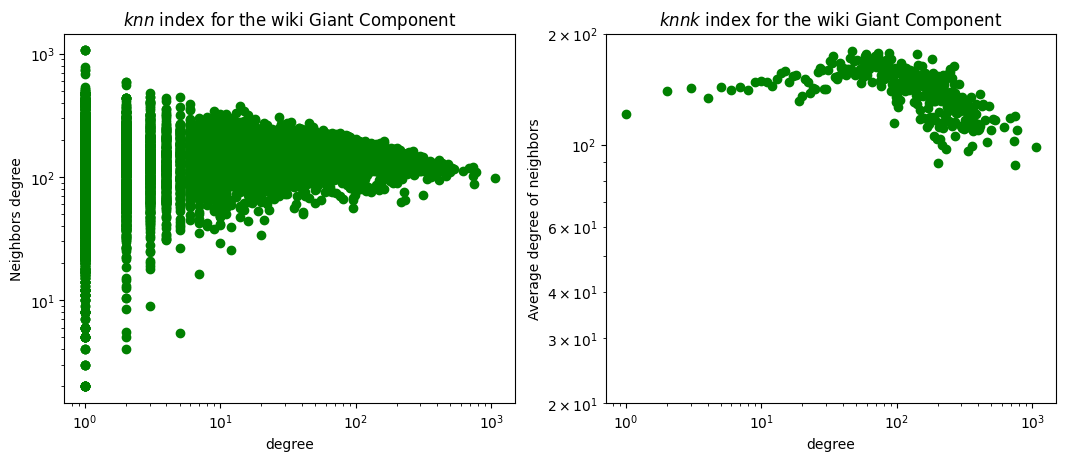

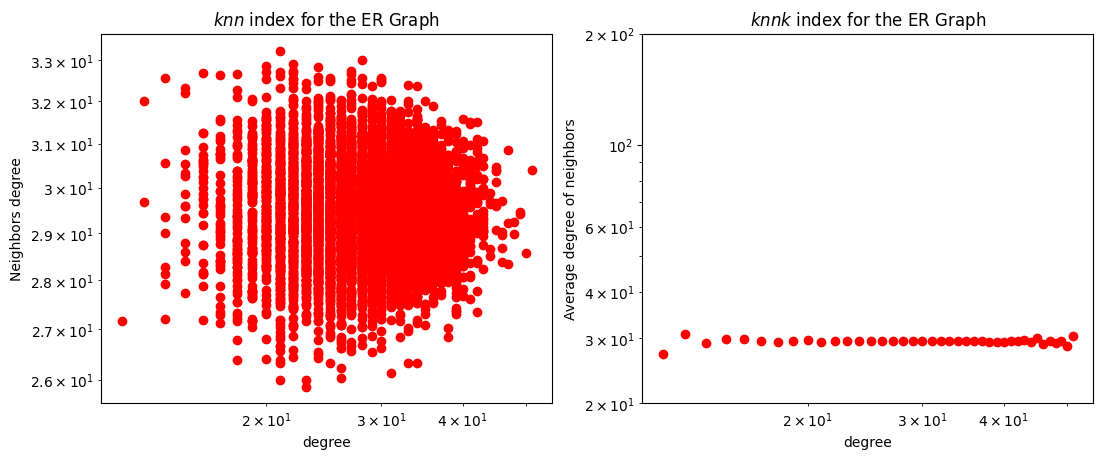

In [298]:
###################
# The knn analysis for WikiGraph 
###################

# average nearest neighbor degree for all vertices (knn)
wiki_knn = nx.average_neighbor_degree(wiki_GC_u)


# average nearest neighbor degree of vertices with same degree value
wiki_knnk = nx.average_degree_connectivity(wiki_GC_u)
wiki_knnk = dict(sorted(wiki_knnk.items()))


deg_list=[x[1] for x in list(wiki_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, wiki_knn.values(), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the wiki Giant Component")

_ = ax2.loglog(wiki_knnk.keys(), wiki_knnk.values(), 'go')
_ = ax2.set_ylim(20,200)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the wiki Giant Component")


################################################################################################
# The knn analysis for ER

# average nearest neighbor degree for all vertices (knn)
er_knn = nx.average_neighbor_degree(er_wiki)


# average nearest neighbor degree of vertices with same degree value
er_knnk = nx.average_degree_connectivity(er_wiki)


er_deg_list=[x[1] for x in list(er_wiki.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(er_deg_list, er_knn.values(), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the ER Graph")

_ = ax2.loglog(er_knnk.keys(), er_knnk.values(), 'ro')
_ = ax2.set_ylim(20,200)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the ER Graph")


### Clustering

In [299]:
print('wiki clustering')
nx.transitivity(wiki_GC_u) # global clustering (C1)
nx.average_clustering(wiki_GC_u, count_zeros=True) # average local clustering (C2)

print('ER clustering')
nx.transitivity(er_wiki) # global clustering (C1)
nx.average_clustering(er_wiki, count_zeros=True) # average local clustering (C2)


wiki clustering


0.12547917487219654

0.14187491841626323

ER clustering


0.004011300066191688

0.004010536533202588

### Shortest Path

In [300]:
# Shortest path length
# generated a sample of 100 vertices as source/destinations
wiki_vs_src = sample(list(wiki_GC_u.nodes()), 1000)
wiki_vs_trg = sample(list(wiki_GC_u.nodes()), 1000)
er_vs_src = sample(list(er_wiki.nodes()), 1000)
er_vs_trg = sample(list(er_wiki.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
wiki_n_hops_u = [nx.shortest_path_length(wiki_GC_u, source = wiki_vs_src[i], target = wiki_vs_trg[i]) for i in range(1000)]
print(f'n hops wiki = {np.mean(wiki_n_hops_u)}')

er_n_hops_u = [nx.shortest_path_length(er_wiki, source = er_vs_src[i], target = er_vs_trg[i]) for i in range(1000)]
print(f'n hops ER = {np.mean(er_n_hops_u)}')


n hops wiki = 3.212
n hops ER = 2.941


## Barabasi-Albert

In [301]:
ba_m = wiki_GC_u.number_of_edges()/wiki_GC_u.number_of_nodes()
ba_m

ba_wiki_all = nx.barabasi_albert_graph(wiki_GC_u.number_of_nodes(), m = int(ba_m))


ba_wiki = ba_wiki_all.subgraph(max(nx.connected_components(ba_wiki_all), key=len))

ba_wiki.number_of_nodes()
wiki_GC_u.number_of_nodes()

ba_wiki.number_of_edges()
wiki_GC_u.number_of_edges()

avg_degree
ba_wiki.number_of_edges()/ba_wiki.number_of_nodes()*2


14.256439286725163

7066

7066

98728

100736

28.512878573450326

27.944523068213982

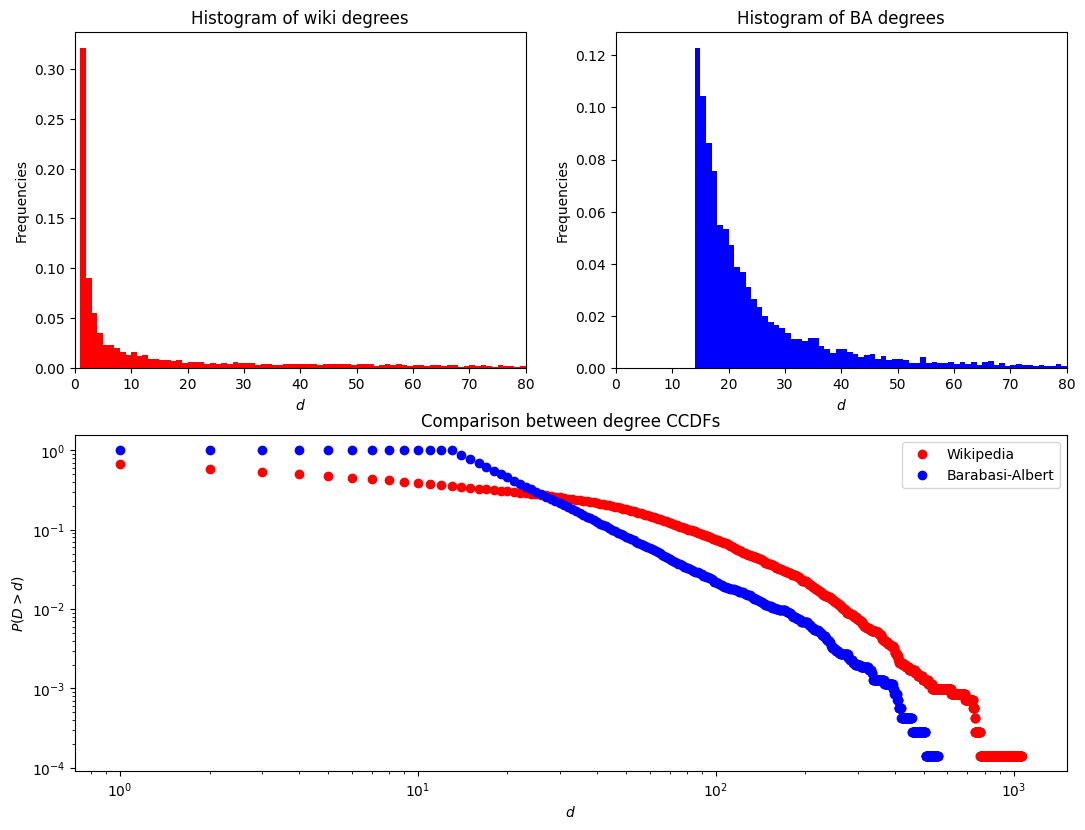

In [302]:
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

gs = gridspec.GridSpec(2, 2)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[1,:])

d_am = list(dict(wiki_GC_u.degree()).values())
_,_,_ = ax1.hist(d_am, bins=range(1,max(d_am)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of wiki degrees")

d_ba = list(dict(ba_wiki.degree()).values())
_,_,_ = ax2.hist(d_ba, bins=range(1,max(d_ba)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of BA degrees")

wiki_ecdf = ECDF(d_am)
ba_ecdf = ECDF(d_ba)
x = np.arange(1,max(d_am)+1)
_ = ax3.loglog(x, 1-wiki_ecdf(x), 'ro', label = 'Wikipedia')
x = np.arange(1,max(d_ba)+1)
_ = ax3.loglog(x, 1-ba_ecdf(x), 'bo', label = 'Barabasi-Albert')
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

In [303]:
# The global assortativity coefficient (Pearson)
nx.degree_pearson_correlation_coefficient(wiki_GC_u)
nx.degree_pearson_correlation_coefficient(ba_wiki)

-0.08330281119562154

-0.011145642033209559

/tmp/ipykernel_19635/2241344330.py:24: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  _ = ax2.set_xlim(0,1000)
/tmp/ipykernel_19635/2241344330.py:50: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  _ = ax2.set_xlim(0,1000)


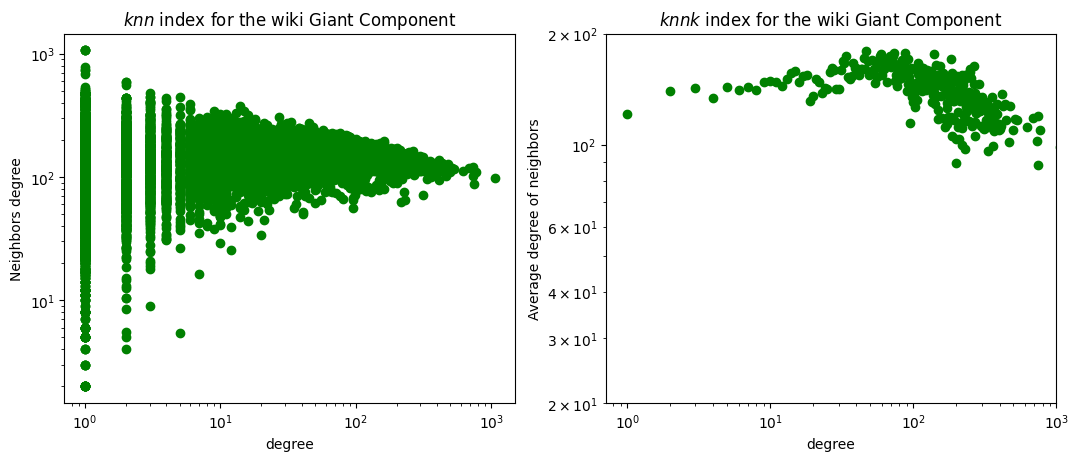

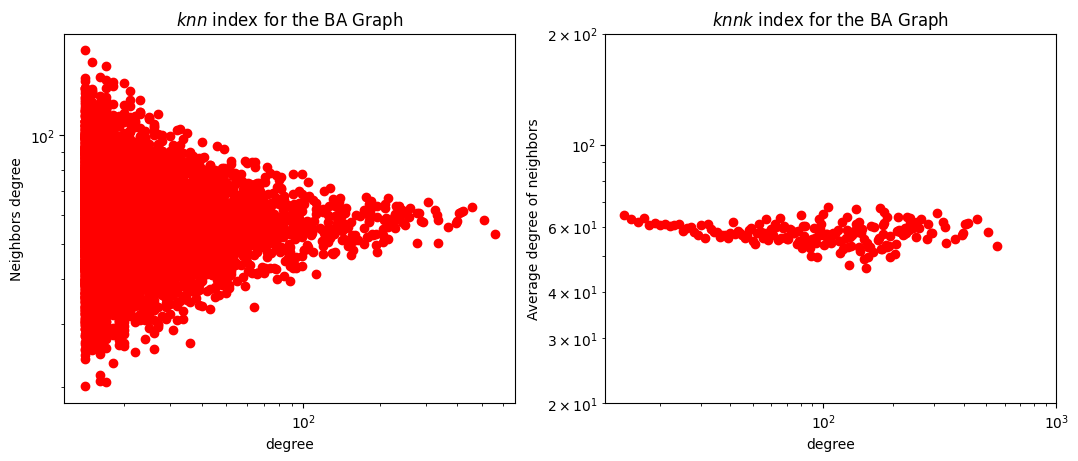

In [304]:
###################
# The knn analysis 
###################

# average nearest neighbor degree for all vertices (knn)
wiki_knn = nx.average_neighbor_degree(wiki_GC_u)


# average nearest neighbor degree of vertices with same degree value
wiki_knnk = nx.average_degree_connectivity(wiki_GC_u)
wiki_knnk = dict(sorted(wiki_knnk.items())) 


deg_list=[x[1] for x in list(wiki_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, list(wiki_knn.values()), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the wiki Giant Component")

_ = ax2.loglog(list(wiki_knnk.keys()), list(wiki_knnk.values()), 'go')
_ = ax2.set_ylim(20,200)
_ = ax2.set_xlim(0,1000)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the wiki Giant Component")

################################################################################################
# Equivalent BA graph

# The knn analysis 
# average nearest neighbor degree for all vertices (knn)
ba_knn = nx.average_neighbor_degree(ba_wiki)


# average nearest neighbor degree of vertices with same degree value
ba_knnk = nx.average_degree_connectivity(ba_wiki)

ba_deg_list=[x[1] for x in list(ba_wiki.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(ba_deg_list, ba_knn.values(), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the BA Graph")

_ = ax2.loglog(ba_knnk.keys(), ba_knnk.values(), 'ro')
_ = ax2.set_ylim(20,200)
_ = ax2.set_xlim(0,1000)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the BA Graph")


### Clustering

In [305]:
nx.transitivity(wiki_GC_u) # global transitivity (C1)
nx.average_clustering(wiki_GC_u, count_zeros=True) # average local transitivity (C2)

nx.transitivity(ba_wiki) # global transitivity (C1)
nx.average_clustering(ba_wiki, count_zeros=True) # average local transitivity (C2)


0.12547917487219654

0.14187491841626323

0.016574634260491227

0.017927428039441293

### Shortest Path

In [306]:
# Shortest path length
# generated a sample of 100 vertices as source/destinations
wiki_vs_src = sample(list(wiki_GC_u.nodes()), 1000)
wiki_vs_trg = sample(list(wiki_GC_u.nodes()), 1000)
ba_vs_src = sample(list(ba_wiki.nodes()), 1000)
ba_vs_trg = sample(list(ba_wiki.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
wiki_n_hops_u = [nx.shortest_path_length(wiki_GC_u, source = wiki_vs_src[i], target = wiki_vs_trg[i]) for i in range(1000)]
np.mean(wiki_n_hops_u)

ba_n_hops_u = [nx.shortest_path_length(ba_wiki, source = ba_vs_src[i], target = ba_vs_trg[i]) for i in range(1000)]
np.mean(ba_n_hops_u)


np.float64(3.295)

np.float64(2.825)

## Configuration model

In [307]:
default_sizes = plt.rcParams["figure.figsize"]
fig_sizes = (2*default_sizes[0], default_sizes[1])
cm_wiki_all = nx.configuration_model(list(dict(wiki_GC_u.degree()).values()))
type(cm_wiki_all)
cm_wiki_all = nx.Graph(cm_wiki_all)
cm_wiki_all.remove_edges_from(nx.selfloop_edges(cm_wiki_all))

# The configuration model does not guarantee connectivity, so this is needed
cm_wiki = cm_wiki_all.subgraph(max(nx.connected_components(cm_wiki_all), key=len))

cm_wiki.number_of_nodes()
wiki_GC_u.number_of_nodes()

cm_wiki.number_of_edges()
wiki_GC_u.number_of_edges()

avg_degree
cm_wiki.number_of_edges()/cm_wiki.number_of_nodes()*2


networkx.classes.multigraph.MultiGraph

7032

7066

96117

100736

28.512878573450326

27.33703071672355

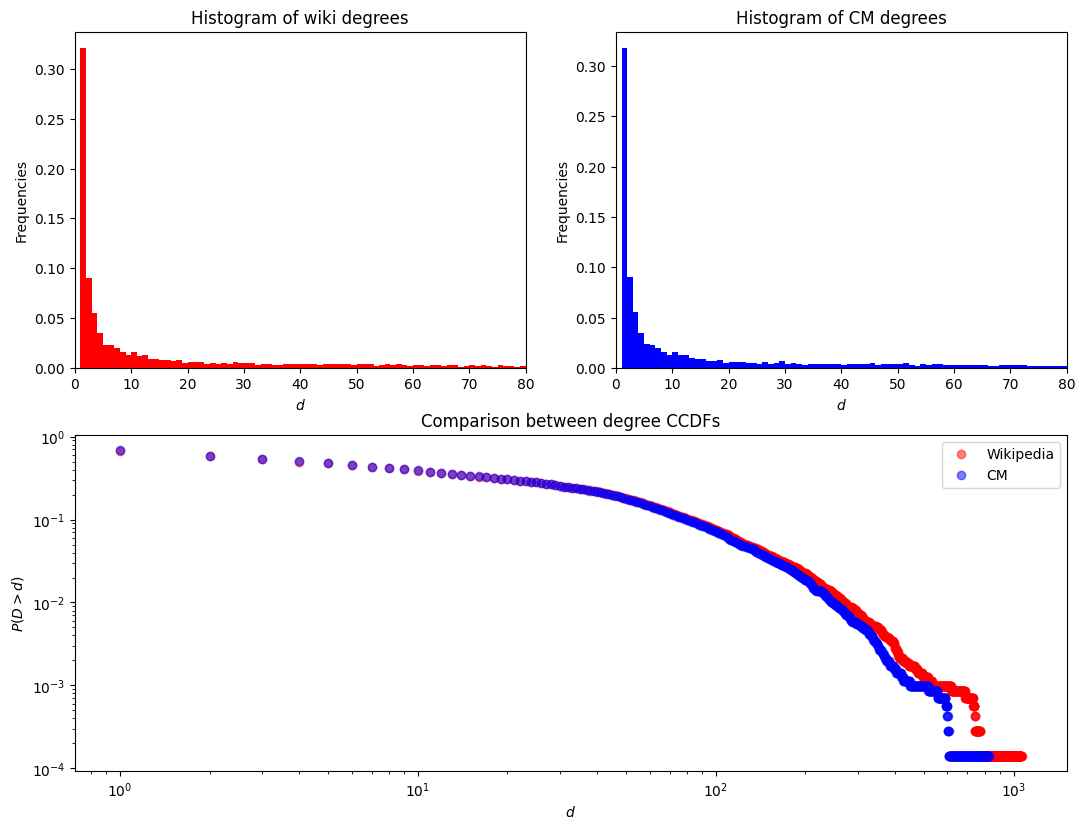

In [308]:
fig_sizes = (fig_sizes[0], 2*default_sizes[1])
f = plt.figure(figsize = fig_sizes)

gs = gridspec.GridSpec(2, 2)


ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[1,:])

d_am = list(dict(wiki_GC_u.degree()).values())
_,_,_ = ax1.hist(d_am, bins=range(1,max(d_am)+2), density = True, color = 'red')
_ = ax1.set_xlim(0,80)
_ = ax1.set_xlabel("$d$")
_ = ax1.set_ylabel("Frequencies")
_ = ax1.set_title("Histogram of wiki degrees")

d_cm = list(dict(cm_wiki.degree()).values()) # conversion to list needed for ECDF
_,_,_ = ax2.hist(d_cm, bins=range(1,max(d_cm)+2), density = True, color = 'blue')
_ = ax2.set_xlim(0,80)
_ = ax2.set_xlabel("$d$")
_ = ax2.set_ylabel("Frequencies")
_ = ax2.set_title("Histogram of CM degrees")

wiki_ecdf = ECDF(d_am)
cm_ecdf = ECDF(d_cm)
x = np.arange(1,max(d_am)+1)
_ = ax3.loglog(x, 1-wiki_ecdf(x), 'ro', label = 'Wikipedia', alpha=0.5)
x = np.arange(1,max(d_cm)+1)
_ = ax3.loglog(x, 1-cm_ecdf(x), 'bo', label = 'CM', alpha = 0.5)
_ = ax3.set_xlabel("$d$")
_ = ax3.set_ylabel("$P(D>d)$")
_ = ax3.set_title("Comparison between degree CCDFs")
_ = ax3.legend(numpoints = 1)

### Assortativity

In [309]:
# The global assortativity coefficient (Pearson)
nx.degree_pearson_correlation_coefficient(wiki_GC_u)
nx.degree_pearson_correlation_coefficient(cm_wiki)

-0.08330281119562154

-0.04272645165570886

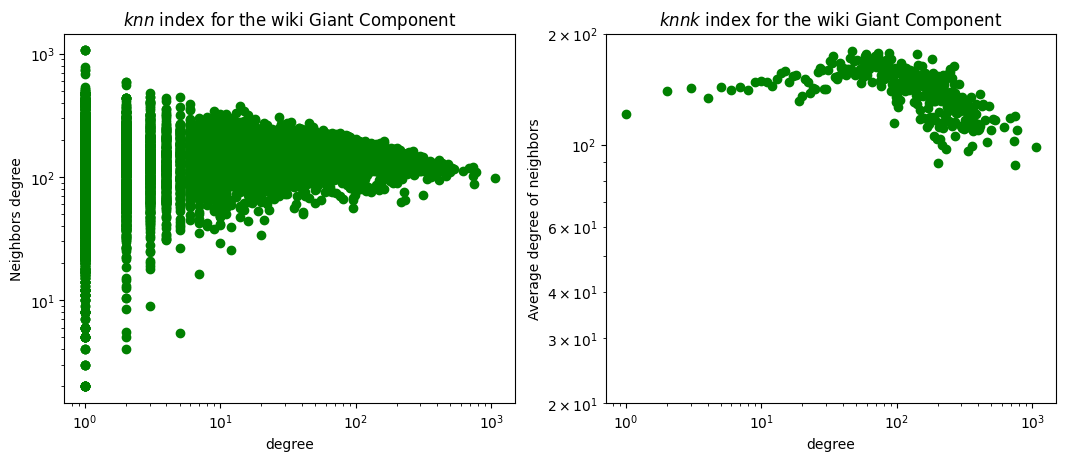

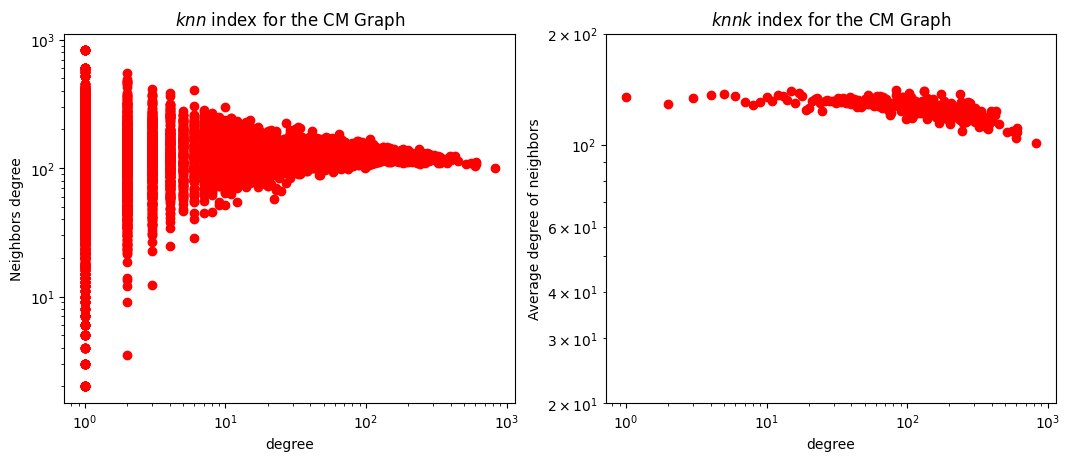

In [310]:
###################
# The knn analysis 
###################

# average nearest neighbor degree for all vertices (knn)
wiki_knn = nx.average_neighbor_degree(wiki_GC_u)

# average nearest neighbor degree of vertices with same degree value
wiki_knnk = nx.average_degree_connectivity(wiki_GC_u)
wiki_knnk = dict(sorted(wiki_knnk.items())) 


deg_list=[x[1] for x in list(wiki_GC_u.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(deg_list, wiki_knn.values(), 'go')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the wiki Giant Component")

_ = ax2.loglog(wiki_knnk.keys(), wiki_knnk.values(), 'go')
_ = ax2.set_ylim(20,200)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the wiki Giant Component")

################################################################################################
# Equivalent CM graph

# average nearest neighbor degree for all vertices (knn)
cm_knn = nx.average_neighbor_degree(cm_wiki)

# average nearest neighbor degree of vertices with same degree value
cm_knnk = nx.average_degree_connectivity(cm_wiki)

cm_deg_list=[x[1] for x in list(cm_wiki.degree())]

_ = fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (2*default_sizes[0], default_sizes[1]))
_ = ax1.loglog(cm_deg_list, cm_knn.values(), 'ro')
_ = ax1.set_xlabel("degree")
_ = ax1.set_ylabel("Neighbors degree")
_ = ax1.set_title("$knn$ index for the CM Graph")

_ = ax2.loglog(cm_knnk.keys(), cm_knnk.values(), 'ro')
_ = ax2.set_ylim(20,200)
_ = ax2.set_xlabel("degree")
_ = ax2.set_ylabel("Average degree of neighbors")
_ = ax2.set_title("$knnk$ index for the CM Graph")


### Clustering

In [311]:
nx.transitivity(wiki_GC_u) # global transitivity (C1)
nx.average_clustering(wiki_GC_u, count_zeros=True) # average local transitivity (C2)

nx.transitivity(cm_wiki) # global transitivity (C1)
nx.average_clustering(cm_wiki, count_zeros=True) # average local transitivity (C2)


0.12547917487219654

0.14187491841626323

0.07481690322829451

0.059049319503552654

### Shortest Path

In [312]:
# Shortest path length
# generated a sample of 100 vertices as source/destinations
wiki_vs_src = sample(list(wiki_GC_u.nodes()), 1000)
wiki_vs_trg = sample(list(wiki_GC_u.nodes()), 1000)
cm_vs_src = sample(list(cm_wiki.nodes()), 1000)
cm_vs_trg = sample(list(cm_wiki.nodes()), 1000)

# computed the UNWEIGHTED shortest paths
wiki_n_hops_u = [nx.shortest_path_length(wiki_GC_u, source = wiki_vs_src[i], target = wiki_vs_trg[i]) for i in range(1000)]
np.mean(wiki_n_hops_u)

cm_n_hops_u = [nx.shortest_path_length(cm_wiki, source = cm_vs_src[i], target = cm_vs_trg[i]) for i in range(1000)]
np.mean(cm_n_hops_u)


np.float64(3.234)

np.float64(3.166)

# 6. ROBUSTEZZA

Generare i tre grafi sintetici di riferimento con le stesse dimensioni (nodi, grado medio) della GC del dataset:

- Simulazione di attacchi sulla GC (non diretta):
- - Random failure: rimozione casuale di nodi
- - Targeted attack (sequenziale per grado): rimozione in ordine decrescente di grado
- Plot della curva di robustezza (frazione nodi rimossi vs. frazione GC sopravvissuta)
- Confronto della robustezza: grafo reale vs. grafo robusto, sotto entrambi gli scenari di attacco
- Discussione: il grafo reale è robusto? Rispetto a quale tipo di attacco è più vulnerabile?


In [313]:
# from igraph import *
import networkx as nx
from copy import deepcopy
import numpy as np
from math import floor
from random import randint, choice
from operator import itemgetter, attrgetter
from datetime import date
from time import localtime, strftime

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [314]:
# a function to generate the "robust version" of a given graph g
def robust_graph(g):
    # compute coefficient A
    g_avg_d = np.mean(list(dict(g.degree()).values()))
    A = ((2 * g_avg_d ** 2 * (g_avg_d-1)**2) / (2*g_avg_d-1)) ** (float(1)/3)
    g_N = g.number_of_nodes()
    
    # compute kmax and kmin according to A
    kmax = int(round(A * (g_N ** (float(2)/3))))
    kmin_low = int(floor((g_N * g_avg_d - kmax) / (g_N - 1))) # if the formula predicts k_min = 1.5, we need to split the nodes betweeen 1 and 2
    
    # as kmin will be rounded, balance nodes with kmin_low and kmin_low+1 to keep
    # the total number of links and avg degree of the original graph
    rem = ((g_N * g_avg_d - kmax) / (g_N - 1)) - kmin_low
    # 1-rem% of nodes must have degree kmin_low, the rest kmin_low+1
    
    # create the degree sequence to generate the graph
    n_low = int(round((g_N-1) * (1-rem)))
    n_high = (g_N-1) - n_low
    seq_deg_low = [kmin_low for i in range(0,n_low)]
    seq_deg_high = [kmin_low+1 for i in range(0,n_high)]
    seq_deg = seq_deg_high + seq_deg_low
    seq_deg.insert(0,kmax)
    
    # create the "robust" graph
    g_rob = nx.configuration_model(seq_deg)
    g_rob = nx.Graph(g_rob) # remove multilink
    g_rob.remove_edges_from(nx.selfloop_edges(g_rob)) # remove self-loops

    # # take only the Giant Component
    g_rob = g_rob.subgraph(max(nx.connected_components(g_rob), key=len))
    # print(nx.is_frozen(g_rob))

    g_rob = nx.Graph(g_rob) #subgraph freezes the graph (nodes cannot be removed from a freezed graph), this is needed to unfrozen it
    # print(nx.is_frozen(g_rob))
    return g_rob

In [315]:
# set of functions to actually perform the attacks

DEBUG = True
GRANUL = 1000

sim_attacks = ["targ_deg_sim"]
seq_attacks = ["random", "targ_deg_seq"]
supported_attacks = sim_attacks + seq_attacks

# the list of nodes to attack in case of simultaneous attacks of type att_type
# assumes that vertices have a name, and returns the list of vertices to be attacked, by name
def attack_list(g, att_type):
    vert_cent = []
    if att_type == "targ_deg_sim":    
        # tuples with names and degrees
        vert_cent = list(g.degree())

    # sort by the centrality metric in decreasing order
    vert_cent.sort(key=itemgetter(1), reverse=True)
    # # no need to kill the last node
    del vert_cent[-1]
    # the IDs of the vertices to be killed, in order of killing
    kill_names = [elem[0] for elem in vert_cent] # [ (1, 100), (34, 98), ...]
    
    return kill_names


# executes a random attack pattern until no node is left, and returns the list of GC proportions
# with respect to the original graph
def attack(g_orig, att_type):
    
    # check that the attack can be done
    if att_type not in supported_attacks:
        print ("Attack " + att_type + " is not supported")
        return None

    # deepcopy to avoid modifications to the original graph
    g = deepcopy(g_orig) # another way to copy graphs (less efficient than networkX native copy())
    
    # prepare for the output list
    # each element is a tuple in the following form
    # (fraction of removed vertices, fraction of vertices still in the GC)
    initial_size = g.number_of_nodes() # this implies that we assume we are working with the giant component
    GC_frac = [(0,1)]
    
    # count the # of killed vertices
    killed = 0
    
    # simultaneous attacks
    if att_type in sim_attacks:
        kill_list = attack_list(g, att_type)

        for kill_name in kill_list:
            g.remove_node(kill_name)
            killed += 1
            # compute the new GC size relative to the original one
            new_GC_size = len(max(nx.connected_components(g), key=len))
            new_point = (float(killed)/initial_size, float(new_GC_size)/initial_size)
            GC_frac.append(new_point)
            if DEBUG and (killed % GRANUL == 0):
                print (initial_size - killed, new_point)
                if killed % (10*GRANUL) == 0:
                    print ('\n', end = "")
    
    # sequential attacks
    else:
        to_be_killed = g.number_of_nodes()
        while to_be_killed > 1:
            # pick the id of the node to attack
            if att_type == "random":
                kill_name = choice(list(dict(g.degree()).keys()))
            elif att_type == "targ_deg_seq":
                deg_dic = dict(g.degree())
                kill_name = max(deg_dic, key=deg_dic.get)

            # kill the vertex
            g.remove_node(kill_name)
            killed += 1
            to_be_killed -= 1
            # compute the new GC size relative to the original one
            new_GC_size = len(max(nx.connected_components(g), key=len))
            # the new point in the series (fraction of killed nodes, fraction of nodes in the GC)
            new_point = (float(killed)/initial_size, float(new_GC_size)/initial_size)
            GC_frac.append(new_point)
            
            if DEBUG and (killed % GRANUL == 0):
                print (to_be_killed, new_point)
                if killed % (10*GRANUL) == 0:
                    print ('\n', end = "")

    return GC_frac

# print the resulting robustness data in an ncol format
# <fraction of removed vertices> <fraction of vertices remaining in the GC>
def print_out(lst, file_name):
    try:
        out_file = open(file_name, "w")
        for elem in lst:
            print (elem[0], elem[1], sep = " ", file=out_file)
        out_file.close()
    except:
        print ("Cannot open file for writing output")

In [316]:
# main interface: perform_attacks() is what one should call to attack a graph.
#
# infile is the name of the file with the graph in ncol format
# directed is whether the graph is directed or not
# prefix is the subdir+prefix related to the dataset for the name of the outfile, e.g., fb-wosn/wosn

def perform_attacks(infile, directed, prefix):
    if directed:
        g_dir = nx.read_edgelist(infile, nodetype=int, data=False, create_using=nx.DiGraph())
        g = g_dir.to_undirected()
    else:
        g = nx.read_edgelist(infile, nodetype=int, data=False, create_using=nx.Graph())
    
    # restrict the analysis to the giant component if not already done
    g = nx.subgraph(g, max(list(nx.connected_components(g)), key=len)).copy() # subgraph returns a frozen graph, so we copy it

    # build the robust version of the graph
    g_rob = robust_graph(g)

    print (strftime("\n%H:%M:%S\n", localtime()))

    # robustness of the original graph
    g_orig_frac_random = attack(g, "random")
    out_file = prefix + "_orig_frac_random.txt"
    print_out(g_orig_frac_random, out_file)

    print (strftime("\n%H:%M:%S\n", localtime()))

    #g_orig_frac_deg_sim = attack(g, "targ_deg_sim")
    #out_file = prefix + "_orig_frac_deg_sim.txt"
    #print_out(g_orig_frac_deg_sim, out_file)

    #print (strftime("\n%H:%M:%S\n", localtime()))

    g_orig_frac_deg_seq = attack(g, "targ_deg_seq")
    out_file = prefix + "_orig_frac_deg_seq.txt"
    print_out(g_orig_frac_deg_seq, out_file)

    print (strftime("\n%H:%M:%S\n", localtime()))

    print("Finished with the original graph")

    # robustness of the modified graph
    g_rob_frac_random = attack(g_rob, "random")
    out_file = prefix + "_rob_frac_random.txt"
    print_out(g_rob_frac_random, out_file)

    print (strftime("\n%H:%M:%S\n", localtime()))

    #g_rob_frac_deg_sim = attack(g_rob, "targ_deg_sim")
    #out_file = prefix + "_rob_frac_deg_sim.txt"
    #print_out(g_rob_frac_deg_sim, out_file)

    #print strftime("\n%H:%M:%S\n", localtime())

    g_rob_frac_deg_seq = attack(g_rob, "targ_deg_seq")
    out_file = prefix + "_rob_frac_deg_seq.txt"
    print_out(g_rob_frac_deg_seq, out_file)

    print (strftime("\n%H:%M:%S\n", localtime()))

In [317]:
# Function to read files with the robustness points resulting from an attack

import re

def read_xy(file):
    x = []
    y = []
    f = open(file, 'r')
    for line in f:
        strings = re.findall(r'\d+\.?\d*e?[\+-]?\d?\d?', line)
        x.append(float(strings[0]))
        y.append(float(strings[1]))
    f.close()
    return (x,y)

In [318]:
# Performing attack
print ("Attacking Wiki-Vote")
perform_attacks("./Wiki-Vote.txt", directed=False, prefix="output/wiki_vote")

Attacking Wiki-Vote

17:38:33

6066 (0.1415227851684121, 0.8212567223322955)
5066 (0.2830455703368242, 0.6539767902632324)
4066 (0.42456835550523636, 0.4966034531559581)
3066 (0.5660911406736484, 0.34050382111519956)
2066 (0.7076139258420606, 0.20067930936880837)
1066 (0.8491367110104727, 0.08080951033116332)
66 (0.9906594961788848, 0.0007076139258420605)

17:39:57

6066 (0.1415227851684121, 0.5333993772997453)
5066 (0.2830455703368242, 0.001415227851684121)
4066 (0.42456835550523636, 0.0001415227851684121)
3066 (0.5660911406736484, 0.0001415227851684121)
2066 (0.7076139258420606, 0.0001415227851684121)
1066 (0.8491367110104727, 0.0001415227851684121)
66 (0.9906594961788848, 0.0001415227851684121)

17:40:41

Finished with the original graph
6066 (0.1415227851684121, 0.8584772148315879)
5066 (0.2830455703368242, 0.7169544296631758)
4066 (0.42456835550523636, 0.5754316444947637)
3066 (0.5660911406736484, 0.43390885932635154)
2066 (0.7076139258420606, 0.292244551372771)
1066 (0.8491367110

In [ ]:
# read all the attack files for the various graphs
bk = {}
bk["or_rand"] = read_xy("output/wiki_vote_orig_frac_random.txt")
bk["or_deg_seq"] = read_xy("output/wiki_vote_orig_frac_deg_seq.txt")
bk["rob_rand"] = read_xy("output/wiki_vote_rob_frac_random.txt")
bk["rob_deg_seq"] = read_xy("output/wiki_vote_rob_frac_deg_seq.txt")

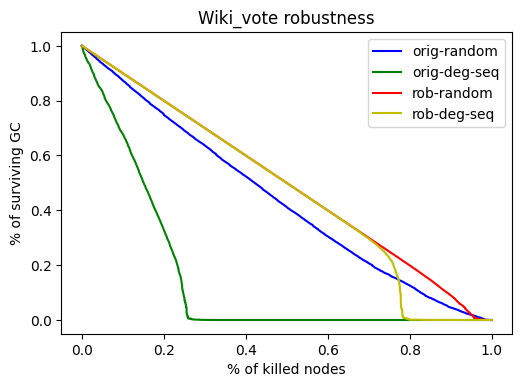

In [ ]:

# %matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# plot the robustness curves

def plot_robust(data, ax, data_str):
    legend_str = data_str + " robustness"
    _ = ax.plot(data["or_rand"][0], data["or_rand"][1], 'b-', label = "orig-random")
    _ = ax.plot(data["or_deg_seq"][0], data["or_deg_seq"][1], 'g-', label = "orig-deg-seq")
    _ = ax.plot(data["rob_rand"][0], data["rob_rand"][1], 'r-', label = "rob-random")
    _ = ax.plot(data["rob_deg_seq"][0], data["rob_deg_seq"][1], 'y-', label = "rob-deg-seq")
    _ = ax.set_xlabel("% of killed nodes")
    _ = ax.set_ylabel("% of surviving GC")
    _ = ax.set_title(legend_str)
    _ = ax.legend()
    

default_sizes = plt.rcParams["figure.figsize"]
fig_sizes = (2*default_sizes[0], 4*default_sizes[1])
f = plt.figure(figsize = fig_sizes)
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# create a 4x2 Grid Specification
gs = gridspec.GridSpec(4, 2)

# add subplots to the figure, using the GridSpec gs
# position [0,0] (upper-left corner)
ax_bk = plt.subplot(gs[0,0])

# BK
plot_robust(bk, ax_bk, "Wiki_vote")


In [ ]:
# Robustness curve pdf generation
f.savefig('robustness_plots.pdf')
